# Week 10 - Ensemble Models

This notebook is the ensemble chunk: Random Forest, AdaBoost, Gradient Boosting, and XGBoost on the SER feature table.

The MiniLearn side is intentionally not trying to be a perfect sklearn clone. Random Forest and AdaBoost are from-scratch enough to show the mechanics, while Gradient Boosting and XGBoost are kept as library comparisons because writing a solid multiclass gradient boosting stack from nothing would turn into a different project.

In [1]:
from pathlib import Path
import sys
import time

ROOT = Path.cwd()
if not (ROOT / "features" / "features.csv").exists():
    maybe_root = ROOT.parent
    if (maybe_root / "features" / "features.csv").exists():
        ROOT = maybe_root
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (
    AdaBoostClassifier as SkAdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier as SkRandomForestClassifier,
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.tree import DecisionTreeClassifier as SkDecisionTreeClassifier
from xgboost import XGBClassifier

from minilearn.classifiers import AdaBoostClassifier, RandomForestClassifier
from minilearn.preprocessing import train_test_split

FEATURE_PATH = ROOT / "features" / "features.csv"
RANDOM_STATE = 432
sns.set_theme(style="whitegrid")

## Load the same feature table

Keeping the split the same matters more than trying to squeeze a couple extra points out of one model. The metadata columns are left out so the models only see extracted audio features, not filename-derived labels or actor bookkeeping.

In [2]:
META_COLS = {
    "filename",
    "emotion",
    "emotion_id",
    "actor",
    "gender",
    "vocalchannel",
    "intensity",
    "statement",
    "repetition",
    "duration",
}

df = pd.read_csv(FEATURE_PATH)
feature_cols = [c for c in df.columns if c not in META_COLS]
X = df[feature_cols].to_numpy(dtype=float)
y = df["emotion_id"].to_numpy()

emotion_names = (
    df[["emotion_id", "emotion"]]
    .drop_duplicates()
    .sort_values("emotion_id")
    .set_index("emotion_id")["emotion"]
    .to_dict()
)
labels = sorted(emotion_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"rows={len(df)}, features={len(feature_cols)}")
print(f"train={len(X_train)}, test={len(X_test)}")
print(emotion_names)

rows=2452, features=407
train=1963, test=489
{1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised'}


## Model setup

The MiniLearn Random Forest is bagging plus random feature subsets. The MiniLearn AdaBoost uses shallow CART trees with weighted resampling, which is a slightly janky but workable way to get boosting without rewriting the tree to support sample weights.

The library side gives the comparison models that should probably win: sklearn Random Forest, sklearn AdaBoost, sklearn Gradient Boosting, and XGBoost. XGBoost needs zero-based class IDs, so the notebook shifts labels down during fit and shifts predictions back after prediction.

In [3]:
models = []

mini_rf = RandomForestClassifier(
    n_estimators=16,
    max_depth=7,
    min_samples_leaf=2,
    max_features="sqrt",
    max_samples=0.85,
    random_state=RANDOM_STATE,
)
models.append(("MiniLearn Random Forest", mini_rf, "minilearn"))

mini_ada = AdaBoostClassifier(
    n_estimators=20,
    learning_rate=0.65,
    max_depth=1,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
)
models.append(("MiniLearn AdaBoost", mini_ada, "minilearn"))

sk_rf = SkRandomForestClassifier(
    n_estimators=180,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
models.append(("sklearn Random Forest", sk_rf, "sklearn"))

sk_ada = SkAdaBoostClassifier(
    estimator=SkDecisionTreeClassifier(max_depth=1, min_samples_leaf=2, random_state=RANDOM_STATE),
    n_estimators=80,
    learning_rate=0.5,
    random_state=RANDOM_STATE,
)
models.append(("sklearn AdaBoost", sk_ada, "sklearn"))

sk_gb = GradientBoostingClassifier(
    n_estimators=25,
    learning_rate=0.08,
    max_depth=2,
    subsample=0.85,
    random_state=RANDOM_STATE,
)
models.append(("sklearn Gradient Boosting", sk_gb, "sklearn"))

xgb = XGBClassifier(
    n_estimators=90,
    max_depth=3,
    learning_rate=0.07,
    subsample=0.85,
    colsample_bytree=0.75,
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=2,
)
models.append(("XGBoost", xgb, "xgboost"))

In [4]:
def evaluate_model(name, model, kind):
    train_y = y_train - 1 if kind == "xgboost" else y_train

    start = time.perf_counter()
    model.fit(X_train, train_y)
    fit_seconds = time.perf_counter() - start

    start = time.perf_counter()
    pred = model.predict(X_test)
    pred_seconds = time.perf_counter() - start
    if kind == "xgboost":
        pred = pred + 1

    return {
        "model": name,
        "kind": kind,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, pred, average="weighted", zero_division=0),
        "fit_seconds": fit_seconds,
        "predict_seconds": pred_seconds,
        "pred": pred,
    }

rows = []
predictions = {}
for name, model, kind in models:
    print(f"fitting {name}...")
    row = evaluate_model(name, model, kind)
    predictions[name] = row.pop("pred")
    rows.append(row)

results = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
results[["accuracy", "macro_f1", "weighted_f1", "fit_seconds", "predict_seconds"]] = results[["accuracy", "macro_f1", "weighted_f1", "fit_seconds", "predict_seconds"]].round(4)
results

fitting MiniLearn Random Forest...


fitting MiniLearn AdaBoost...


fitting sklearn Random Forest...


fitting sklearn AdaBoost...


fitting sklearn Gradient Boosting...


fitting XGBoost...


,model,kind,accuracy,macro_f1,weighted_f1,fit_seconds,predict_seconds
0,XGBoost,xgboost,0.6667,0.6588,0.6647,8.5748,0.0042
1,sklearn Random Forest,sklearn,0.6687,0.6479,0.6658,1.0537,0.1689
2,sklearn Gradient Boosting,sklearn,0.5644,0.5491,0.5608,26.9080,0.0034
3,MiniLearn Random Forest,minilearn,0.4519,0.4300,0.4481,3.8467,0.0185
4,sklearn AdaBoost,sklearn,0.3824,0.3420,0.3710,8.7899,0.0247
5,MiniLearn AdaBoost,minilearn,0.3211,0.2380,0.2607,6.5688,0.0149


## What the models are made out of

This is the structure printout section. I am not dumping whole source files because that gets noisy fast. Instead these are the fitted structures that matter: how many learners exist, what the sampled trees look like, and the weights/errors that make boosting different from bagging.

In [5]:
print(mini_rf.structure_summary(feature_names=feature_cols, max_trees=2, tree_depth=2))

RandomForestClassifier
trees=16, classes=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
bootstrap=True, max_features=sqrt

tree 1: sampled_features=['mfccDD9_mean', 'mfcc11_max', 'mfccD3_std', 'mel43_std', 'mel35_mean', 'mel41_mean', 'mfcc0_median', 'mel95_std']...
if mel23_mean <= -45.3690: samples=1669, impurity=0.864
  if mel43_std <= 20.0546: samples=828, impurity=0.831
    leaf: class=2, samples=626, impurity=0.797
  else:
    leaf: class=3, samples=202, impurity=0.852
else:
  if mel82_mean <= -36.1065: samples=841, impurity=0.812
    leaf: class=6, samples=682, impurity=0.829
  else:
    leaf: class=5, samples=159, impurity=0.540

tree 2: sampled_features=['mfccDD3_std', 'chroma3_std', 'mfcc10_max', 'mfccD10_mean', 'mel26_mean', 'mfcc3_median', 'mel101_std', 'mel118_std']...
if mel28_mean <= -44.5764: samples=1669, impurity=0.868
  if mel110_std <= 12.6163: samples=962, impurity=0.848
    leaf: class=4, samples=532, impuri

In [6]:
print(mini_ada.structure_summary(feature_names=feature_cols, max_estimators=5, tree_depth=1))

AdaBoostClassifier
learners=20, classes=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
learning_rate=0.65, weak_tree_depth=1

learner 1: weight=0.643, error=0.722
if mfcc0_max <= -327.0717: samples=1963, impurity=0.866
  leaf: class=2, samples=689, impurity=0.773
else:
  leaf: class=5, samples=1274, impurity=0.831

learner 2: weight=0.577, error=0.742
if mel67_mean <= -45.5197: samples=1963, impurity=0.862
  leaf: class=4, samples=1314, impurity=0.849
else:
  leaf: class=3, samples=649, impurity=0.748

learner 3: weight=0.492, error=0.767
if mel64_mean <= -47.1232: samples=1963, impurity=0.867
  leaf: class=2, samples=1143, impurity=0.862
else:
  leaf: class=6, samples=820, impurity=0.792

learner 4: weight=0.358, error=0.801
if rms_std <= 0.0357: samples=1963, impurity=0.870
  leaf: class=3, samples=1800, impurity=0.870
else:
  leaf: class=5, samples=163, impurity=0.489

learner 5: weight=0.429, error=0.783
if mfcc0_max <= -290

In [7]:
print("sklearn RandomForestClassifier")
print(f"trees={len(sk_rf.estimators_)}, classes={list(sk_rf.classes_)}")
print(f"first_tree_depth={sk_rf.estimators_[0].get_depth()}, first_tree_leaves={sk_rf.estimators_[0].get_n_leaves()}")
print(f"max_features_={sk_rf.estimators_[0].max_features_}")
print()

print("sklearn AdaBoostClassifier")
print(f"learners={len(sk_ada.estimators_)}, classes={list(sk_ada.classes_)}")
print("first 10 estimator weights:", np.round(sk_ada.estimator_weights_[:10], 3).tolist())
print("first 10 estimator errors:", np.round(sk_ada.estimator_errors_[:10], 3).tolist())
print()

print("sklearn GradientBoostingClassifier")
print(f"estimators_shape={sk_gb.estimators_.shape}, classes={list(sk_gb.classes_)}")
print(f"first_stage_first_class_tree_depth={sk_gb.estimators_[0, 0].get_depth()}")
print()

print("XGBClassifier")
print({k: xgb.get_params()[k] for k in ["n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree", "tree_method"]})
dump = xgb.get_booster().get_dump(with_stats=False)[0].splitlines()[:8]
print("first booster tree, first lines:")
print("\n".join(dump))

sklearn RandomForestClassifier
trees=180, classes=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
first_tree_depth=17, first_tree_leaves=318
max_features_=20

sklearn AdaBoostClassifier
learners=80, classes=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
first 10 estimator weights: [0.511, 0.444, 0.434, 0.324, 0.259, 0.289, 0.281, 0.368, 0.346, 0.272]
first 10 estimator errors: [0.716, 0.742, 0.746, 0.785, 0.807, 0.797, 0.799, 0.77, 0.778, 0.802]

sklearn GradientBoostingClassifier
estimators_shape=(25, 8), classes=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
first_stage_first_class_tree_depth=2

XGBClassifier
{'n_estimators': 90, 'max_depth': 3, 'learning_rate': 0.07, 'subsample': 0.85, 'colsample_bytree': 0.75, 'tree_method': 'hist'}
first booster tree, first lines:
0:[f126<0.298657119] yes=1,no=2,missing=2
	1:[f

## Result chart

Random Forest and XGBoost usually have the advantage here because they can handle ugly feature interactions without making every single tree carry the full problem alone. AdaBoost is included because it is the classic boosting example, but this speech-emotion feature table is noisy enough that stump boosting is not magically fixed by adding more stumps.

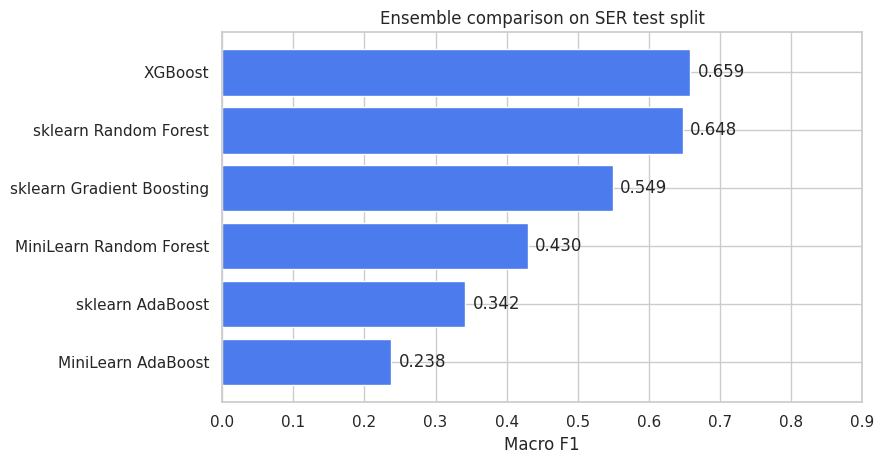

In [8]:
plot_df = results.sort_values("macro_f1", ascending=True)
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(plot_df["model"], plot_df["macro_f1"], color="#4b7bec")
ax.set_xlabel("Macro F1")
ax.set_xlim(0, max(0.9, plot_df["macro_f1"].max() + 0.08))
ax.set_title("Ensemble comparison on SER test split")
for i, value in enumerate(plot_df["macro_f1"]):
    ax.text(value + 0.01, i, f"{value:.3f}", va="center")
plt.tight_layout()
plt.show()

## Best model class behavior

The single summary score hides a lot. Emotion labels can be unevenly hard: calm/neutral and happy/surprised style mistakes are easy to mix up because the features are summarizing whole clips, not doing a full temporal model.

best model: XGBoost
              precision    recall  f1-score   support

     neutral       0.79      0.58      0.67        38
        calm       0.69      0.84      0.76        75
       happy       0.72      0.61      0.66        75
         sad       0.61      0.57      0.59        75
       angry       0.78      0.76      0.77        75
     fearful       0.58      0.60      0.59        75
     disgust       0.62      0.79      0.70        38
   surprised       0.54      0.53      0.53        38

    accuracy                           0.67       489
   macro avg       0.67      0.66      0.66       489
weighted avg       0.67      0.67      0.66       489



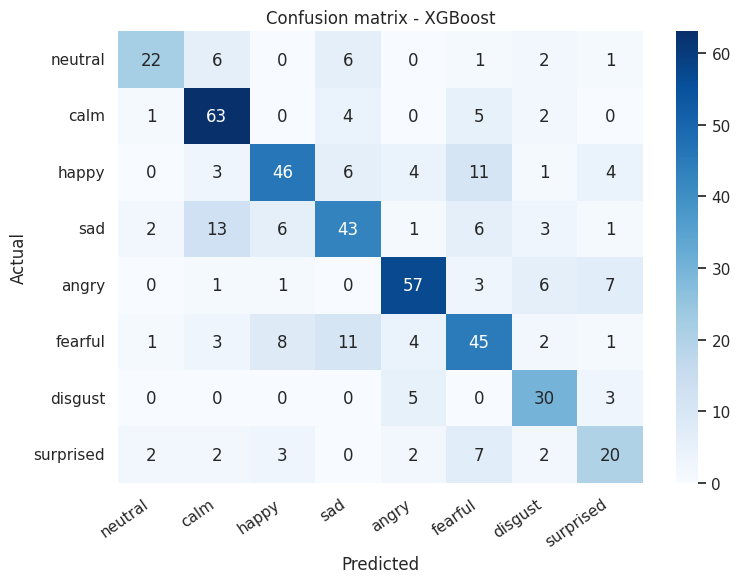

In [9]:
best_name = results.iloc[0]["model"]
best_pred = predictions[best_name]
print("best model:", best_name)
print(classification_report(y_test, best_pred, labels=labels, target_names=[emotion_names[i] for i in labels], zero_division=0))

cm = confusion_matrix(y_test, best_pred, labels=labels)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[emotion_names[i] for i in labels],
    yticklabels=[emotion_names[i] for i in labels],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix - {best_name}")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Feature importance check

This is just a sanity check that the tree ensembles are using recognizable audio summary features instead of acting like everything is equally useful. The names also make it easier to explain what the models latched onto in the writeup.

In [10]:
def top_importances(name, importances, n=12):
    return pd.DataFrame({"model": name, "feature": feature_cols, "importance": importances}).sort_values("importance", ascending=False).head(n)

importance_tables = [
    top_importances("MiniLearn RF", mini_rf.feature_importances_),
    top_importances("sklearn RF", sk_rf.feature_importances_),
    top_importances("XGBoost", xgb.feature_importances_),
]
importance_df = pd.concat(importance_tables, ignore_index=True)
importance_df

,model,feature,importance
0,MiniLearn RF,mfccDD0_std,0.028128
1,MiniLearn RF,mel23_mean,0.021674
2,MiniLearn RF,mel22_mean,0.021265
3,MiniLearn RF,mel64_mean,0.018345
4,MiniLearn RF,mel61_mean,0.018019
5,MiniLearn RF,mel82_mean,0.017222
6,MiniLearn RF,mel84_mean,0.016888
7,MiniLearn RF,mel43_std,0.015485
8,MiniLearn RF,mel35_std,0.014993
9,MiniLearn RF,mel7_std,0.014093


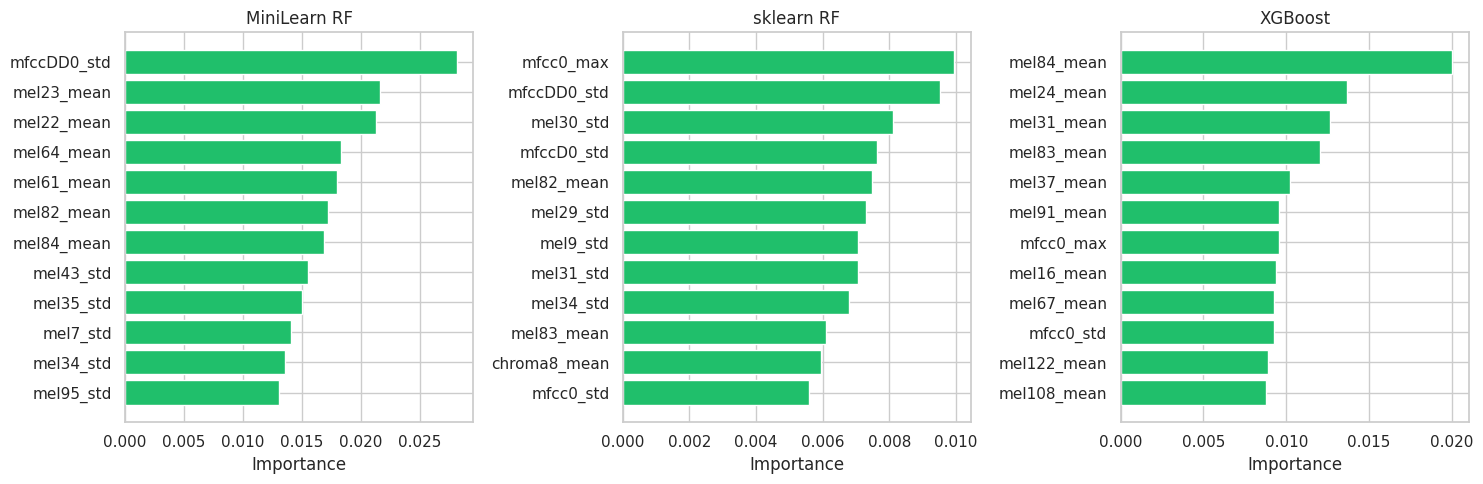

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=False)
for ax, model_name in zip(axes, ["MiniLearn RF", "sklearn RF", "XGBoost"]):
    sub = importance_df[importance_df["model"] == model_name].sort_values("importance")
    ax.barh(sub["feature"], sub["importance"], color="#20bf6b")
    ax.set_title(model_name)
    ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## Notes for the report

- Random Forest is bagging: many noisy-ish trees vote together. That makes it less brittle than one CART tree because one bad split does not decide the whole result.
- AdaBoost is boosting: later weak learners focus more on points previous learners missed. That is elegant, but on noisy speech emotion labels it can chase messy examples.
- Gradient Boosting is also boosting, but it builds trees to correct residual/loss gradients instead of only reweighting wrong examples like classic AdaBoost.
- XGBoost is the cleaned-up industrial version of gradient boosted trees: shrinkage, subsampling, regularization, and a fast tree builder. It is not from scratch here, but it is the fair strong-model benchmark.
- MiniLearn Random Forest being worse than sklearn is expected. This version samples a feature subset per tree, while sklearn samples features at individual splits and has many optimized edge cases.
- The main result to carry forward is the best ensemble score, plus the fact that ensembles are stronger than the single-tree CART notebook because they reduce variance or correct mistakes across learners.